<a href="https://colab.research.google.com/github/NelvaAdalit/Machine-Learning-SIS420-Datasets/blob/main/06_Credit_Approval_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 Dataset 06: Credit Approval

## 📋 Descripción del Dataset
Este dataset contiene información sobre solicitudes de tarjetas de crédito. Por razones de confidencialidad, todos los nombres de las variables y sus valores han sido anonimizados mediante símbolos.
* **Archivo utilizado:** `crx.data`.
* **Objetivo:** Predecir la aprobación (`+`) o rechazo (`-`) del crédito mediante clasificación binaria.
* **Dimensiones:** 690 instancias y 16 atributos.

## 🛠️ Archivos en esta carpeta
* `crx.data`: Datos crudos con variables anónimas.
* `crx.names`: Documentación técnica de los atributos.
* `06_Credit_Approval_Analysis.ipynb`: Cuaderno de Colab con el preprocesamiento detallado.

## ⚙️ Trabajo y Preparación de Datos
1. **Anonimización:** Se asignaron identificadores `A1` a `A16` para manejar los datos sin cabecera original.
2. **Tratamiento de Nulos:** Se identificaron valores perdidos (`?`) en el 5% de los datos y se imputaron mediante **Moda** para datos nominales y **Media** para continuos.
3. **Codificación Masiva:** Se transformaron todas las columnas categóricas (nominales) a valores numéricos mediante `LabelEncoder`.
4. **Normalización Z-Score:** Se escalaron las variables continuas para evitar que los rangos numéricos afecten el rendimiento del modelo.

---
*Preparación realizada para la Primera Parte del Examen Parcial.*

In [8]:
# ==============================================================================
# 1. CONEXIÓN Y LIBRERÍAS
# ==============================================================================
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
print("Librerías cargadas correctamente.")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Librerías cargadas correctamente.


In [9]:
# Nombres de columnas según crx.names
columnas = [f'A{i}' for i in range(1, 17)]
ruta_credit = '/content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/06_Credit Approval/crx.data'

# USAMOS na_values='?' para que Pandas reconozca los nulos reales
df = pd.read_csv(ruta_credit, names=columnas, na_values='?')

print("="*70)
print(f"DATASET CREDIT APPROVAL CARGADO: {df.shape[0]} filas y {df.shape[1]} columnas")
print("="*70)
display(df.head(3))

DATASET CREDIT APPROVAL CARGADO: 690 filas y 16 columnas


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.00,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.46,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.50,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+


In [10]:
print("="*70)
print(" FASE 1: TRATAMIENTO DE VALORES NULOS (SÍMBOLOS '?')")
print("="*70)

# ANTES: Ahora mostrará los nulos en A1, A2, A4, A5, A6, A7, A14
nulos_antes = df.isnull().sum()
print("\n🔴 [ANTES] Columnas con datos faltantes detectados:")
print(nulos_antes[nulos_antes > 0])

# PROCESO: Imputación
for columna in df.columns:
    if df[columna].dtype == 'object':
        df[columna] = df[columna].fillna(df[columna].mode()[0])
    else:
        df[columna] = df[columna].fillna(df[columna].mean())

# DESPUÉS
print(f"\n🟢 [DESPUÉS] Total de nulos restantes en el dataset: {df.isnull().sum().sum()} ✅")

 FASE 1: TRATAMIENTO DE VALORES NULOS (SÍMBOLOS '?')

🔴 [ANTES] Columnas con datos faltantes detectados:
A1     12
A2     12
A4      6
A5      6
A6      9
A7      9
A14    13
dtype: int64

🟢 [DESPUÉS] Total de nulos restantes en el dataset: 0 ✅


### 4. Diccionario de Variables (Nombres Probables de Negocio)
Aunque el dataset original usa etiquetas A1-A16, la investigación académica sugiere que representan los siguientes factores críticos de riesgo crediticio:

* **Gender (A1)**: Género del solicitante.
* **Age (A2)**: Edad.
* **Debt (A3)**: Nivel de deuda actual.
* **Married (A4)**: Estado civil.
* **BankCustomer (A5)**: Si ya es cliente del banco.
* **EducationLevel (A6)**: Nivel educativo alcanzado.
* **Ethnicity (A7)**: Etnia/Raza.
* **YearsEmployed (A8)**: Años de antigüedad laboral.
* **PriorDefault (A9)**: Historial de impagos previos (Crítico).
* **Employed (A10)**: Si tiene empleo actual.
* **CreditScore (A11)**: Puntaje crediticio interno.
* **DriversLicense (A12)**: Posesión de licencia de conducir.
* **Citizen (A13)**: Tipo de ciudadanía.
* **ZipCode (A14)**: Código postal de residencia.
* **Income (A15)**: Ingresos anuales.
* **ApprovalStatus (A16 - Target)**: Resultado (+ Aprobado, - Rechazado).

In [11]:
# ==============================================================================
# 4. ANTES Y DESPUÉS: CODIFICACIÓN CON NOMBRES DE NEGOCIO (50 FILAS)
# ==============================================================================
# Mapeamos los nombres probables identificados por investigadores de la UCI
mapping_names = {
    'A1': 'Gender', 'A2': 'Age', 'A3': 'Debt', 'A4': 'Married',
    'A5': 'BankCustomer', 'A6': 'EducationLevel', 'A7': 'Ethnicity',
    'A8': 'YearsEmployed', 'A9': 'PriorDefault', 'A10': 'Employed',
    'A11': 'CreditScore', 'A12': 'DriversLicense', 'A13': 'Citizen',
    'A14': 'ZipCode', 'A15': 'Income', 'A16': 'ApprovalStatus'
}
df_named = df.rename(columns=mapping_names)

print("="*80)
print(" FASE 2: TRANSFORMACIÓN DE SÍMBOLOS A VARIABLES DE NEGOCIO (50 FILAS)")
print("="*80)

pd.set_option('display.max_rows', 50)
columnas_texto = df_named.select_dtypes(include=['object']).columns.tolist()

# ANTES
print("\n🔴 [ANTES] Datos originales anonimizados con sus nombres de negocio:")
display(df_named[columnas_texto].head(50))

# PROCESO: LabelEncoder
encoder = LabelEncoder()
for col in columnas_texto:
    df_named[col] = encoder.fit_transform(df_named[col].astype(str))

# DESPUÉS
print("\n🟢 [DESPUÉS] Variables de riesgo crediticio ya codificadas numéricamente:")
display(df_named[columnas_texto].head(50))

df = df_named.copy() # Actualizamos el dataframe principal
pd.reset_option('display.max_rows')

 FASE 2: TRANSFORMACIÓN DE SÍMBOLOS A VARIABLES DE NEGOCIO (50 FILAS)

🔴 [ANTES] Datos originales anonimizados con sus nombres de negocio:


,Gender,Married,BankCustomer,EducationLevel,Ethnicity,PriorDefault,Employed,DriversLicense,Citizen,ApprovalStatus
0,b,u,g,w,v,t,t,f,g,+
1,a,u,g,q,h,t,t,f,g,+
2,a,u,g,q,h,t,f,f,g,+
3,b,u,g,w,v,t,t,t,g,+
4,b,u,g,w,v,t,f,f,s,+
5,b,u,g,m,v,t,f,t,g,+
6,b,u,g,r,h,t,f,t,g,+
7,a,u,g,cc,v,t,f,f,g,+
8,b,y,p,k,h,t,f,f,g,+
9,b,y,p,w,v,t,f,t,g,+



🟢 [DESPUÉS] Variables de riesgo crediticio ya codificadas numéricamente:


,Gender,Married,BankCustomer,EducationLevel,Ethnicity,PriorDefault,Employed,DriversLicense,Citizen,ApprovalStatus
0,1,1,0,12,7,1,1,0,0,0
1,0,1,0,10,3,1,1,0,0,0
2,0,1,0,10,3,1,0,0,0,0
3,1,1,0,12,7,1,1,1,0,0
4,1,1,0,12,7,1,0,0,2,0
5,1,1,0,9,7,1,0,1,0,0
6,1,1,0,11,3,1,0,1,0,0
7,0,1,0,2,7,1,0,0,0,0
8,1,2,2,8,3,1,0,0,0,0
9,1,2,2,12,7,1,0,1,0,0


In [14]:
# ==============================================================================
# 5. MATRIZ FINAL Y NORMALIZACIÓN
# ==============================================================================
# A16 es el objetivo (clase)
X = df.drop('ApprovalStatus', axis=1).values
y = df['ApprovalStatus'].values

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print("="*70)
print("¡MATRIZ X_norm CREADA EXITOSAMENTE!")
print(f"Forma de X_norm: {X_norm.shape}")
print("="*70)

¡MATRIZ X_norm CREADA EXITOSAMENTE!
Forma de X_norm: (690, 15)


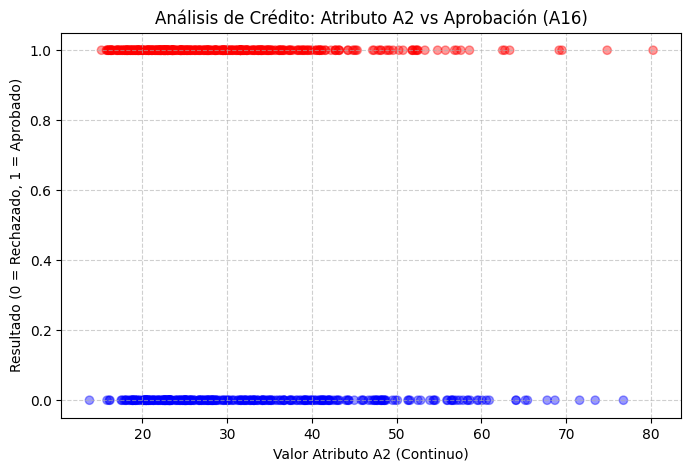

In [16]:
# ==============================================================================
# 6. VISUALIZACIÓN EXPLORATORIA
# ==============================================================================
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['ApprovalStatus'], c=df['ApprovalStatus'], cmap='bwr', alpha=0.4)
plt.title('Análisis de Crédito: Atributo A2 vs Aprobación (A16)')
plt.xlabel('Valor Atributo A2 (Continuo)')
plt.ylabel('Resultado (0 = Rechazado, 1 = Aprobado)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()